<div class="alert alert-block alert-info" style="padding:20px;color:white;margin:auto;font-size:300%;text-align:center;display:fill;border-radius:60px;background-color:#37006f;overflow:hidden;font-weight:800">Linear vs Non-linear Separable datasets</div>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from mpl_toolkits.mplot3d import Axes3D

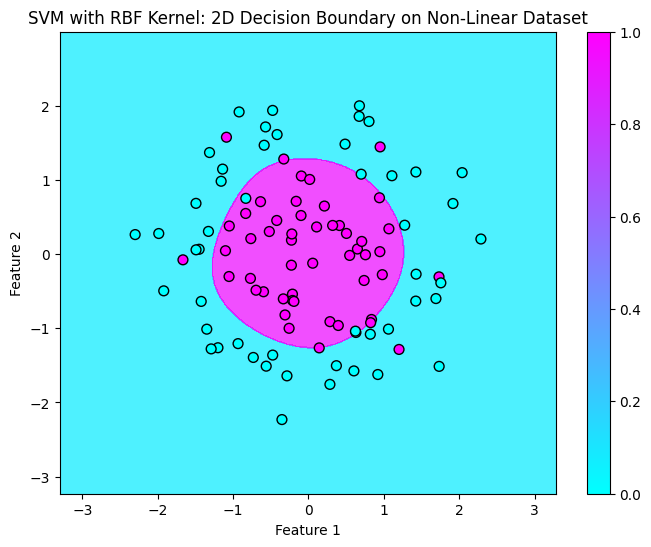

In [10]:
# Step 1: Generate a synthetic 2D dataset (non-linearly separable)
X, y = make_circles(n_samples=100, noise=0.2, factor=0.5, random_state=42)

# Step 2: Standardize the features (important for SVM)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Step 3: Train a Support Vector Classifier with an RBF kernel
svm_rbf = SVC(kernel='rbf', gamma='scale', C=10)
svm_rbf.fit(X_scaled, y)

# Step 4: Create a mesh grid for decision boundary visualization (2D)
x_min, x_max = X_scaled[:, 0].min() - 1, X_scaled[:, 0].max() + 1
y_min, y_max = X_scaled[:, 1].min() - 1, X_scaled[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                     np.arange(y_min, y_max, 0.01))

# Step 5: Predict the class for each point in the mesh grid
Z = svm_rbf.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Step 6: Plot the decision boundary in 2D
plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.75, cmap='cool')

# Plot the dataset points in 2D
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y, s=50, edgecolors='k', cmap='cool')

# Labels and title
plt.title("SVM with RBF Kernel: 2D Decision Boundary on Non-Linear Dataset")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.colorbar()

# Show plot
plt.show()

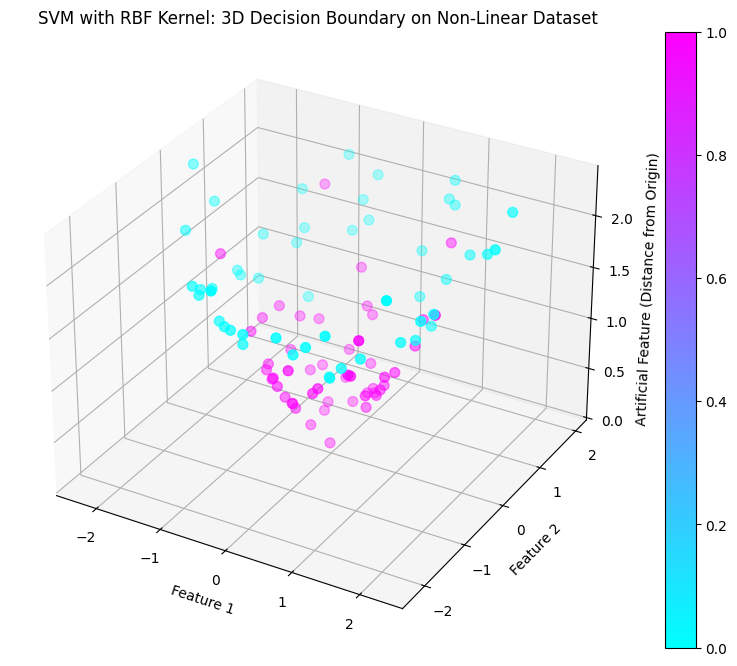

In [11]:
# Step 7: For the 3D visualization, we'll create an artificial third dimension (e.g., use the distance from the origin)
X_3d = np.hstack([X_scaled, np.linalg.norm(X_scaled, axis=1).reshape(-1, 1)])  # Add a 3rd dimension based on distance

# Create meshgrid for 3D decision boundary visualization
x_min, x_max = X_3d[:, 0].min() - 1, X_3d[:, 0].max() + 1
y_min, y_max = X_3d[:, 1].min() - 1, X_3d[:, 1].max() + 1
z_min, z_max = X_3d[:, 2].min() - 1, X_3d[:, 2].max() + 1
xx, yy, zz = np.meshgrid(np.arange(x_min, x_max, 0.2),
                         np.arange(y_min, y_max, 0.2),
                         np.arange(z_min, z_max, 0.2))

# **Fix**: Predict the class using only the first two features (xx, yy) in the mesh grid
Z_3d = svm_rbf.predict(np.c_[xx.ravel(), yy.ravel()])  # Use only the first two dimensions for prediction
Z_3d = Z_3d.reshape(xx.shape)

# Step 8: Plot the decision boundary in 3D using scatter plot
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot of the dataset points in 3D
scatter = ax.scatter(X_3d[:, 0], X_3d[:, 1], X_3d[:, 2], c=y, s=50, cmap='cool')

# Labels and title
ax.set_title("SVM with RBF Kernel: 3D Decision Boundary on Non-Linear Dataset")
ax.set_xlabel("Feature 1")
ax.set_ylabel("Feature 2")
ax.set_zlabel("Artificial Feature (Distance from Origin)")

# Colorbar for 3D plot
fig.colorbar(scatter)

# Show plot
plt.show()